First 5 rows:
     Flight_ID        Date     Month Day_of_Week Departure_City  Arrival_City  \
0  PK2026_0001  2026-06-09      June     Tuesday         Jeddah     Islamabad   
1  PK2026_0002  2026-08-12    August   Wednesday          Dubai  Kuala Lumpur   
2  PK2026_0003  2026-04-20     April      Monday           Doha        Lahore   
3  PK2026_0004  2026-12-07  December      Monday         Jeddah        Lahore   
4  PK2026_0005  2026-05-04       May      Monday         Lahore          Doha   

      Route_Type Aircraft_Type  Flight_Duration_Minutes  Passengers  ...  \
0  International   Airbus A320                       83         120  ...   
1  International   Airbus A320                      284         179  ...   
2  International        ATR 72                      333          69  ...   
3  International    Boeing 777                      330         291  ...   
4  International    Boeing 737                      283         159  ...   

   Ticket_Price_USD  Revenue_USD  Delay_Mi

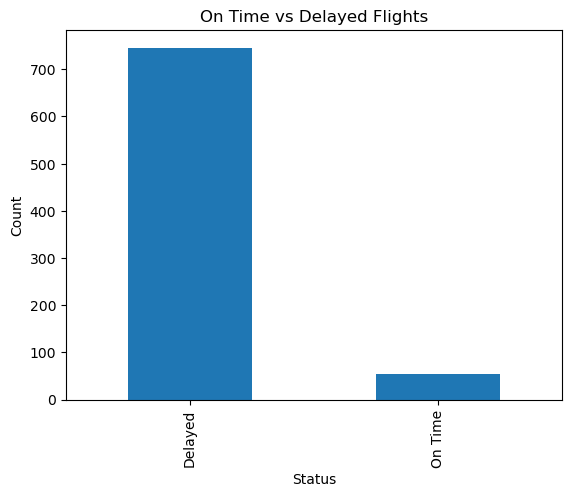


After preprocessing:
   Month  Day_of_Week  Departure_City  Arrival_City  Route_Type  \
0      6            5               3             2           1   
1      1            6               1             5           1   
2      0            1               0             6           1   
3      2            1               3             6           1   
4      8            1               6             0           1   

   Aircraft_Type  Flight_Duration_Minutes  Passengers  Seat_Capacity  \
0              1                       83         120            180   
1              1                      284         179            180   
2              0                      333          69             70   
3              3                      330         291            350   
4              2                      283         159            160   

   Load_Factor_%  Ticket_Price_USD  Revenue_USD  Delay_Minutes  \
0          66.67              1140       136800            220   
1         

/lib/python3.13/site-packages/sklearn/neural_network/_multilayer_perceptron.py:780: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



Training Deep Model...

Confusion Matrix:
[[  5   4]
 [  4 147]]

AUC Score: 0.9256806475349522

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.56      0.56         9
           1       0.97      0.97      0.97       151

    accuracy                           0.95       160
   macro avg       0.76      0.76      0.76       160
weighted avg       0.95      0.95      0.95       160



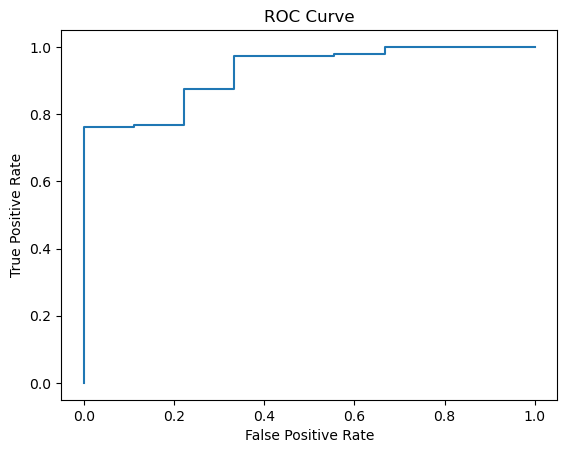

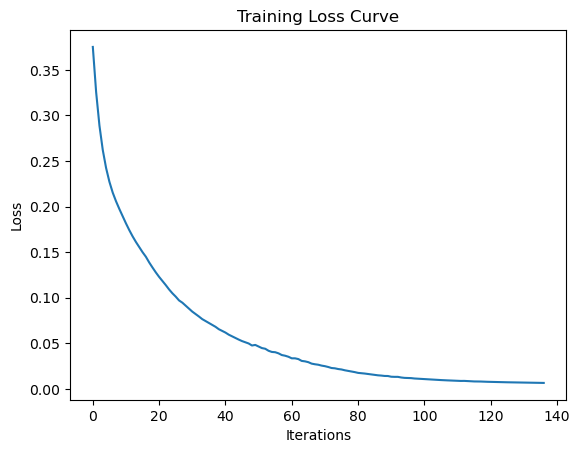


Number of Errors: 8

Sample Errors:
     Actual  Predicted
621       0          1
635       0          1
529       1          0
265       0          1
192       0          1

NEW MODEL RESULTS:
AUC: 0.9359823399558499
Accuracy: 0.94375


In [1]:
# ============================================================
# PIA 2026 SMART FLIGHT DATASET - NEURAL NETWORK PROJECT
# Predict: On_Time_Status (Delayed vs On Time)
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, roc_auc_score, classification_report, roc_curve
from sklearn.neural_network import MLPClassifier

# =========================
# 2. LOAD DATASET
# =========================

df = pd.read_csv("archive.csv")

print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

# =========================
# 3. BASIC VISUALIZATION
# =========================

df['On_Time_Status'].value_counts().plot(kind='bar')
plt.title("On Time vs Delayed Flights")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

# =========================
# 4. PREPROCESSING
# =========================

# Drop unnecessary columns
df = df.drop(['Flight_ID', 'Date', 'Customer_Feedback'], axis=1)

# Convert target to binary
df['On_Time_Status'] = df['On_Time_Status'].map({
    'On Time': 0,
    'Delayed': 1
})

# Encode categorical features
categorical_cols = df.select_dtypes(include=['object']).columns

encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

# Fill missing values
df = df.fillna(df.mean())

print("\nAfter preprocessing:")
print(df.head())

# =========================
# 5. SPLIT DATA
# =========================

X = df.drop('On_Time_Status', axis=1)
y = df['On_Time_Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================
# 6. FEATURE SCALING
# =========================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================
# 7. MODEL 1 - BASIC NN
# =========================

model = MLPClassifier(
    hidden_layer_sizes=(16,),
    max_iter=300,
    learning_rate_init=0.001
)

print("\nTraining Basic Model...")
model.fit(X_train, y_train)

# =========================
# 8. MODEL 2 - DEEP NN
# =========================

deep_model = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    max_iter=500,
    learning_rate_init=0.001,
    alpha=0.01
)

print("\nTraining Deep Model...")
deep_model.fit(X_train, y_train)

# =========================
# 9. EVALUATION
# =========================

y_pred = deep_model.predict(X_test)
y_prob = deep_model.predict_proba(X_test)[:, 1]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# AUC Score
auc = roc_auc_score(y_test, y_prob)
print("\nAUC Score:", auc)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# =========================
# 10. VISUALIZATIONS
# =========================

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr)
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.show()

# Loss Curve (for deep model)
plt.plot(deep_model.loss_curve_)
plt.title("Training Loss Curve")
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.show()

# =========================
# 11. ERROR ANALYSIS
# =========================

errors = (y_test != y_pred)

print("\nNumber of Errors:", errors.sum())

print("\nSample Errors:")
print(pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})[errors].head())

# =========================
# 12. HYPERPARAMETER TEST MODEL
# =========================

model_test = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    max_iter=800,
    learning_rate_init=0.0005,
    alpha=0.001
)

model_test.fit(X_train, y_train)

y_pred_test = model_test.predict(X_test)
y_prob_test = model_test.predict_proba(X_test)[:, 1]

print("\nNEW MODEL RESULTS:")
print("AUC:", roc_auc_score(y_test, y_prob_test))
print("Accuracy:", model_test.score(X_test, y_test))

# =========================
# END OF PROJECT
# =========================